# Cross-over levelling dependence on line length

In [1]:
%load_ext autoreload
%autoreload 2


import logging

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as pio
import verde as vd

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()
pio.renderers.default = "notebook"

## Load data

This notebook uses the data and intersections dataframes from the previous notebook `Cross-over-errors`.

In [8]:
data_df = pd.read_csv("data/AGAP_magnetic_survey_processed_blocked.csv")
data_df = data_df[
    [
        "easting",
        "northing",
        "height",
        "line",
        "unixtime",
        "distance_along_line",
        "mag",
    ]
]

data_df = data_df.rename(columns={"distance_along_line": "along_line_distance"})

# define flight lines vs tie lines
data_df["line_type"] = np.where(data_df.line >= 142, 1, 0)

# keep a subset of tie lines and just 1 flight line
line = 77
lines_to_keep = [
    150,
    151,
    152,
    153,
    154,
    155,
    156,
    157,
    158,
    159,
    160,
    161,
    162,
    164,
    165,
    166,
    167,
]
lines_to_keep = np.append(lines_to_keep, line)

data_df = data_df[(data_df.line.isin(lines_to_keep))]

# convert dataframe into geodataframe
data_df = gpd.GeoDataFrame(
    data_df,
    geometry=gpd.points_from_xy(data_df.easting, data_df.northing),
    crs="EPSG:3031",
)

data_df.head()

,easting,northing,height,line,unixtime,along_line_distance,mag,line_type,geometry
155245,613796.184341,108259.149034,3793.1,77,1.230970e+09,72.986528,35.54,0,POINT (613796.184 108259.149)
155246,614014.105815,108288.966298,3791.7,77,1.230970e+09,292.943124,35.18,0,POINT (614014.106 108288.966)
155247,614232.757811,108315.269624,3791.9,77,1.230970e+09,513.172378,34.43,0,POINT (614232.758 108315.27)
155248,614414.514181,108337.253486,3793.5,77,1.230970e+09,696.255616,33.60,0,POINT (614414.514 108337.253)
155249,614594.969358,108363.481597,3794.7,77,1.230970e+09,878.614978,32.61,0,POINT (614594.969 108363.482)


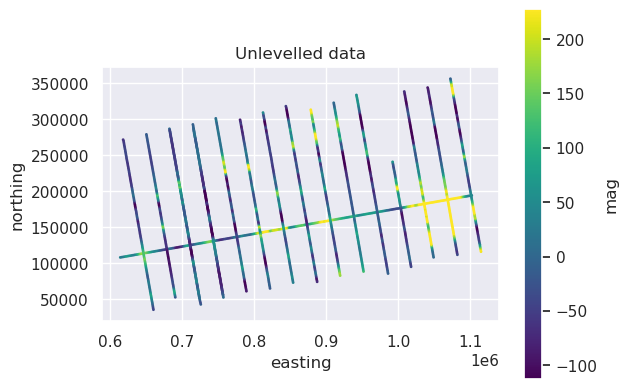

In [9]:
vmin, vmax = vd.minmax(data_df.mag, min_percentile=5, max_percentile=95)
ax = data_df[::10].plot.scatter(
    "easting",
    "northing",
    c="mag",
    s=1,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    title="Unlevelled data",
)
ax.set_aspect("equal")

In [11]:
# calculate theoretical intersection points
inters = airbornegeo.create_intersection_table(
    data_df,
    line_column="line",
    method="pairs",
)

# interpolate mag data at intersections
data_df, inters = airbornegeo.interpolate_intersections(
    data_df,
    inters,
    to_interp="mag",
    interp_on="along_line_distance",
    window_width=500,
    method="cubic",
    extrapolate=False,
    line_column="line",
)

# calculate cross-over errors
inters = airbornegeo.calculate_crossover_errors(
    data_df,
    inters,
    data_col="mag",
    line_column="line",
)

Line pairs:   0%|          | 0/17 [00:00<?, ?it/s]

INFO:airbornegeo:found 17 intersections


Interpolating segments:   0%|          | 0/18 [00:00<?, ?it/s]

In [12]:
airbornegeo.plot_line_and_crosses(
    data_df,
    line=line,
    x="along_line_distance",
    y=["mag"],
    y_axes=[1],
    plot_inters=True,
    line_column="line",
)

In [13]:
line_df = data_df[data_df.line == line]
ints = inters[(inters.line1 == line) | (inters.line2 == line)]
mistie_col = "mistie_0"

for ind, row in line_df[line_df.is_intersection].iterrows():
    # search intersections for mistie values
    mistie_row = ints[
        ((ints.line1 == line) & (ints.line2 == row.intersecting_line))
        | ((ints.line1 == row.intersecting_line) & (ints.line2 == line))
    ]
    # add misties to line dataframe
    line_df.loc[ind, mistie_col] = mistie_row[mistie_col].to_numpy()


# line_df = airbornegeo.interpolate_missing_pointwise(
#     line_df,
#     to_interp=mistie_col,
#     interp_on="distance_along_line",
#     method="linear",
#     extrapolate=True,
# )

## Level with fitting a trend to the cross-overs

In [15]:
data_df, inters_ = airbornegeo.crossover_pair_levelling(
    data_df,
    inters,
    lines_to_level=[line],
    data_col="mag",
    line_column="line",
    distance_column="along_line_distance",
    levelled_col="mag_levelled_trend0",
    degree=0,
)

# calculate levelling correction
data_df["levelling_correction_trend0"] = data_df.mag - data_df.mag_levelled_trend0

In [16]:
data_df, inters_ = airbornegeo.crossover_pair_levelling(
    data_df,
    inters,
    lines_to_level=[line],
    data_col="mag",
    line_column="line",
    distance_column="along_line_distance",
    levelled_col="mag_levelled_trend1",
    degree=1,
)

# calculate levelling correction
data_df["levelling_correction_trend1"] = data_df.mag - data_df.mag_levelled_trend1

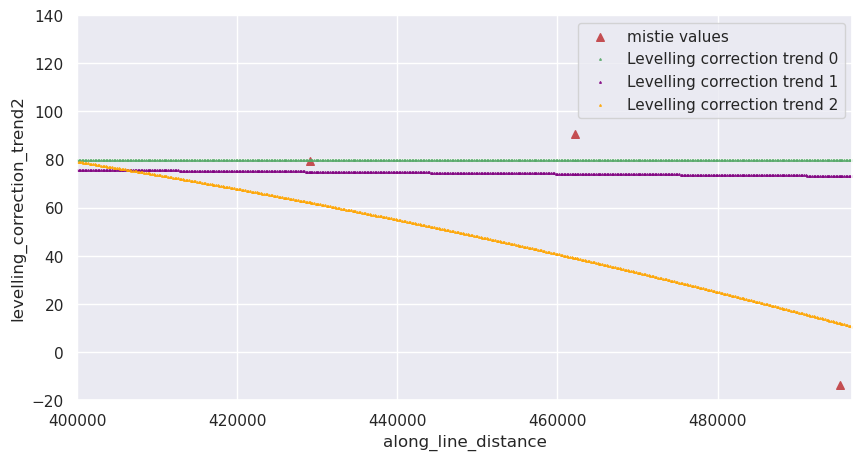

In [19]:
data_df, inters_ = airbornegeo.crossover_pair_levelling(
    data_df,
    inters,
    lines_to_level=[line],
    data_col="mag",
    line_column="line",
    distance_column="along_line_distance",
    levelled_col="mag_levelled_trend2",
    degree=2,
)

# calculate levelling correction
data_df["levelling_correction_trend2"] = data_df.mag - data_df.mag_levelled_trend2

fig, axs = plt.subplots(1, 1, figsize=(10, 5))

ax = line_df[line_df.is_intersection].plot.scatter(
    "along_line_distance",
    mistie_col,
    marker="^",
    s=30,
    c="r",
    ax=axs,
    label="mistie values",
)
ax = data_df[data_df.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_trend0",
    marker="^",
    s=1,
    c="g",
    ax=axs,
    label="Levelling correction trend 0",
)
ax = data_df[data_df.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_trend1",
    marker="^",
    s=1,
    c="purple",
    ax=axs,
    label="Levelling correction trend 1",
)
ax = data_df[data_df.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_trend2",
    marker="^",
    s=1,
    c="orange",
    ax=axs,
    label="Levelling correction trend 2",
)

# zoom in on the end of the line
max_dist_to_shorten_line = 400e3
ax.set_xlim(
    max_dist_to_shorten_line, data_df[data_df.line == line].along_line_distance.max()
)
ax.set_ylim(-20, 140)
plt.show()

## Wavelength-based levelling

In the above cells, we calculate cross-over errors, and fit trends of specified orders to these values, yielding a levelling correction. For trend orders greater than 1, these levelling corrections are dependent on line length or the position of the cross-overs, in this case, all of them being at the end of the line. 

An alternative method is to interpolate these cross-over errors along the entire line and low-pass filter the results. This means we can choose the wavelength of our levelling correction, and our levelling corrections are independent of line length.

In [21]:
data_df, inters_ = airbornegeo.crossover_pair_levelling(
    data_df,
    inters,
    lines_to_level=[line],
    data_col="mag",
    line_column="line",
    levelled_col="mag_levelled_filter",
    distance_column="along_line_distance",
    filter="g100000",
)

# calculate levelling correction
data_df["levelling_correction_100km_filter"] = data_df.mag - data_df.mag_levelled_filter

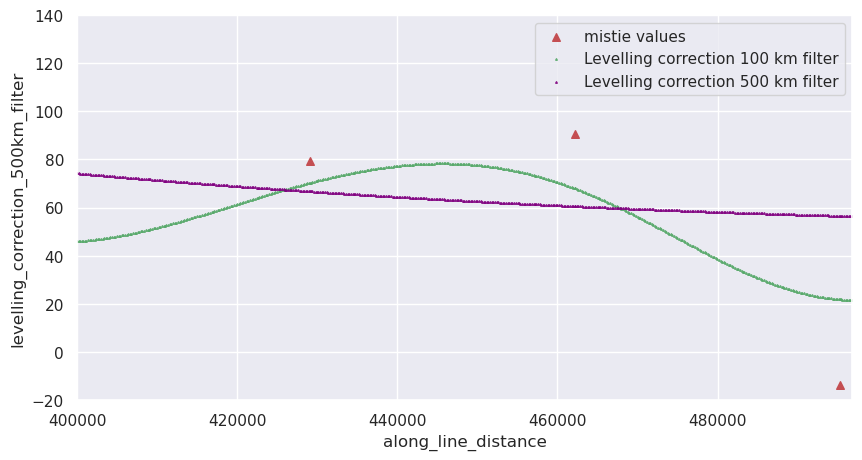

In [24]:
data_df, inters_ = airbornegeo.crossover_pair_levelling(
    data_df,
    inters,
    lines_to_level=[line],
    data_col="mag",
    line_column="line",
    levelled_col="mag_levelled_filter",
    distance_column="along_line_distance",
    filter="g500000",
)

# calculate levelling correction
data_df["levelling_correction_500km_filter"] = data_df.mag - data_df.mag_levelled_filter

fig, axs = plt.subplots(1, 1, figsize=(10, 5))

ax = line_df[line_df.is_intersection].plot.scatter(
    "along_line_distance",
    mistie_col,
    marker="^",
    s=30,
    c="r",
    ax=axs,
    label="mistie values",
)
ax = data_df[data_df.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_100km_filter",
    marker="^",
    s=1,
    c="g",
    ax=axs,
    label="Levelling correction 100 km filter",
)
ax = data_df[data_df.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_500km_filter",
    marker="^",
    s=1,
    c="purple",
    ax=axs,
    label="Levelling correction 500 km filter",
)

# zoom in on the end of the line
ax.set_xlim(
    max_dist_to_shorten_line, data_df[data_df.line == line].along_line_distance.max()
)
ax.set_ylim(-20, 140)
plt.show()

# Repeat with a shorter version of the line

In [25]:
# shorten the line of interest
to_drop = data_df[
    (data_df.line == line) & (data_df.along_line_distance < max_dist_to_shorten_line)
]
data_df = data_df.drop(to_drop.index)

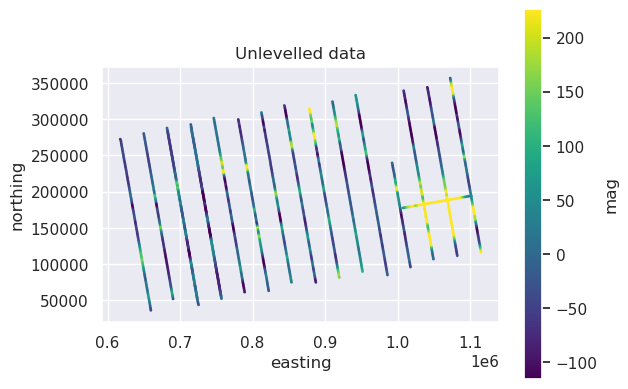

In [26]:
vmin, vmax = vd.minmax(data_df.mag, min_percentile=5, max_percentile=95)
ax = data_df[::10].plot.scatter(
    "easting",
    "northing",
    c="mag",
    s=1,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    title="Unlevelled data",
)
ax.set_aspect("equal")

In [28]:
# calculate theoretical intersection points
inters = airbornegeo.create_intersection_table(
    data_df,
    line_column="line",
    method="pairs",
)

# interpolate mag data at intersections
data_df, inters = airbornegeo.interpolate_intersections(
    data_df,
    inters,
    to_interp="mag",
    interp_on="along_line_distance",
    window_width=500,
    method="cubic",
    extrapolate=False,
    line_column="line",
)

# calculate cross-over errors
inters = airbornegeo.calculate_crossover_errors(
    data_df,
    inters,
    data_col="mag",
    line_column="line",
)

Line pairs:   0%|          | 0/17 [00:00<?, ?it/s]

INFO:airbornegeo:found 3 intersections


Interpolating segments:   0%|          | 0/18 [00:00<?, ?it/s]

In [29]:
airbornegeo.plot_line_and_crosses(
    data_df,
    line=line,
    x="along_line_distance",
    y=["mag"],
    y_axes=[1],
    plot_inters=True,
    line_column="line",
)

In [30]:
line_df = data_df[data_df.line == line]
ints = inters[(inters.line1 == line) | (inters.line2 == line)]
mistie_col = "mistie_0"

for ind, row in line_df[line_df.is_intersection].iterrows():
    # search intersections for mistie values
    mistie_row = ints[
        ((ints.line1 == line) & (ints.line2 == row.intersecting_line))
        | ((ints.line1 == row.intersecting_line) & (ints.line2 == line))
    ]
    # add misties to line dataframe
    line_df.loc[ind, mistie_col] = mistie_row[mistie_col].to_numpy()


# line_df = airbornegeo.interpolate_missing_pointwise(
#     line_df,
#     to_interp=mistie_col,
#     interp_on="distance_along_line",
#     method="linear",
#     extrapolate=True,
# )

## Level with fitting a trend to the cross-overs

In [32]:
data_df, inters_ = airbornegeo.crossover_pair_levelling(
    data_df,
    inters,
    lines_to_level=[line],
    data_col="mag",
    levelled_col="mag_levelled_trend0",
    distance_column="along_line_distance",
    degree=0,
    line_column="line",
)

# calculate levelling correction
data_df["levelling_correction_trend0"] = data_df.mag - data_df.mag_levelled_trend0

In [33]:
data_df, inters_ = airbornegeo.crossover_pair_levelling(
    data_df,
    inters,
    lines_to_level=[line],
    data_col="mag",
    levelled_col="mag_levelled_trend1",
    distance_column="along_line_distance",
    degree=1,
    line_column="line",
)

# calculate levelling correction
data_df["levelling_correction_trend1"] = data_df.mag - data_df.mag_levelled_trend1

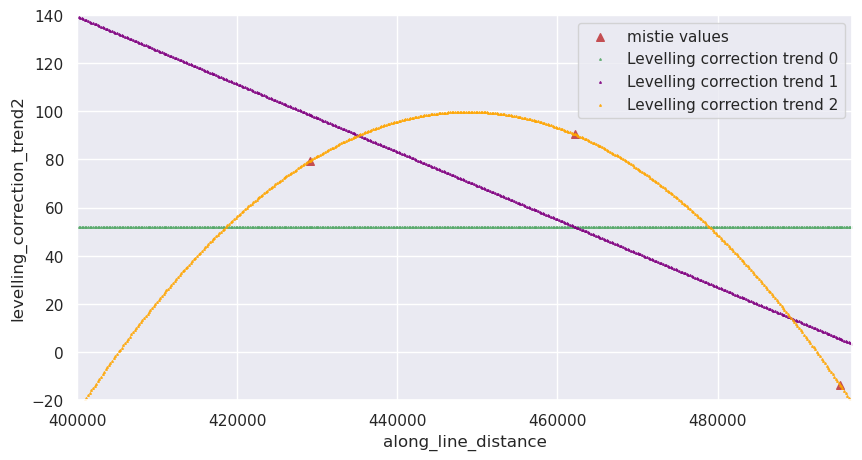

In [35]:
data_df, inters_ = airbornegeo.crossover_pair_levelling(
    data_df,
    inters,
    lines_to_level=[line],
    data_col="mag",
    levelled_col="mag_levelled_trend2",
    distance_column="along_line_distance",
    degree=2,
    line_column="line",
)

# calculate levelling correction
data_df["levelling_correction_trend2"] = data_df.mag - data_df.mag_levelled_trend2

fig, axs = plt.subplots(1, 1, figsize=(10, 5))

ax = line_df[line_df.is_intersection].plot.scatter(
    "along_line_distance",
    mistie_col,
    marker="^",
    s=30,
    c="r",
    ax=axs,
    label="mistie values",
)
ax = data_df[data_df.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_trend0",
    marker="^",
    s=1,
    c="g",
    ax=axs,
    label="Levelling correction trend 0",
)
ax = data_df[data_df.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_trend1",
    marker="^",
    s=1,
    c="purple",
    ax=axs,
    label="Levelling correction trend 1",
)
ax = data_df[data_df.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_trend2",
    marker="^",
    s=1,
    c="orange",
    ax=axs,
    label="Levelling correction trend 2",
)

ax.set_xlim(
    max_dist_to_shorten_line, data_df[data_df.line == line].along_line_distance.max()
)
ax.set_ylim(-20, 140)

plt.show()

## Wavelength-based levelling

In the above cells, we calculate cross-over errors, and fit trends of specified orders to these values, yielding a levelling correction. For trend orders greater than 1, these levelling corrections are dependent on line length or the position of the cross-overs, in this case, all of them being at the end of the line. 

An alternative method is to interpolate these cross-over errors along the entire line and low-pass filter the results. This means we can choose the wavelength of our levelling correction, and our levelling corrections are independent of line length.

In [37]:
data_df, inters_ = airbornegeo.crossover_pair_levelling(
    data_df,
    inters,
    lines_to_level=[line],
    data_col="mag",
    levelled_col="mag_levelled_filter",
    distance_column="along_line_distance",
    filter="g100000",
    line_column="line",
)

# calculate levelling correction
data_df["levelling_correction_100km_filter"] = data_df.mag - data_df.mag_levelled_filter

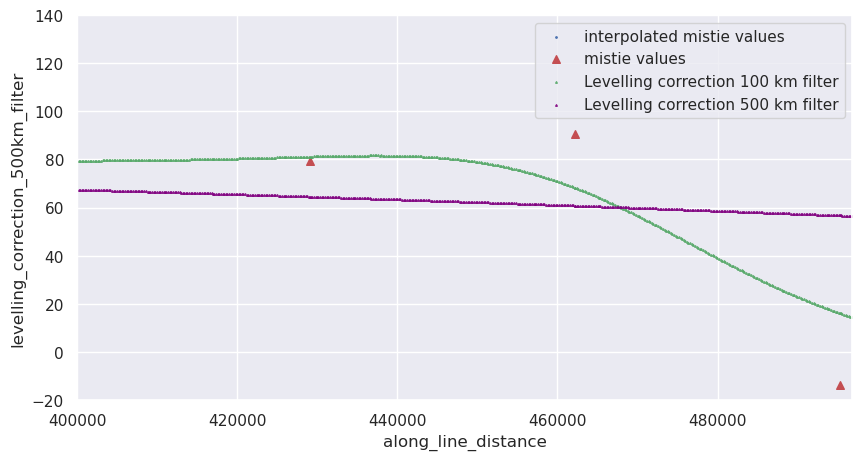

In [39]:
data_df, inters_ = airbornegeo.crossover_pair_levelling(
    data_df,
    inters,
    lines_to_level=[line],
    data_col="mag",
    levelled_col="mag_levelled_filter",
    distance_column="along_line_distance",
    filter="g500000",
    line_column="line",
)

# calculate levelling correction
data_df["levelling_correction_500km_filter"] = data_df.mag - data_df.mag_levelled_filter

fig, axs = plt.subplots(1, 1, figsize=(10, 5))

ax = line_df.plot.scatter(
    "along_line_distance",
    mistie_col,
    s=1,
    ax=axs,
    label="interpolated mistie values",
)
ax = line_df[line_df.is_intersection].plot.scatter(
    "along_line_distance",
    mistie_col,
    marker="^",
    s=30,
    c="r",
    ax=axs,
    label="mistie values",
)
ax = data_df[data_df.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_100km_filter",
    marker="^",
    s=1,
    c="g",
    ax=axs,
    label="Levelling correction 100 km filter",
)
ax = data_df[data_df.line == line].plot.scatter(
    "along_line_distance",
    "levelling_correction_500km_filter",
    marker="^",
    s=1,
    c="purple",
    ax=axs,
    label="Levelling correction 500 km filter",
)

ax.set_xlim(
    max_dist_to_shorten_line, data_df[data_df.line == line].along_line_distance.max()
)
ax.set_ylim(-20, 140)
plt.show()